<a href="https://colab.research.google.com/github/furkanaydinn/3D_Car_Park_Simulation/blob/main/arac_motor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

furkanaydin5555_arac_motor_veri_seti_path = kagglehub.dataset_download('furkanaydin5555/arac-motor-veri-seti')

print('Data source import complete.')


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/furkanaydin5555/arac-motor-veri-seti/doe_1_ooxml.xlsx


In [ ]:
!pip install fastexcel

import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 31.0 MB/s eta 0:00:0000:0100:01


In [ ]:
# Veri Setini Yükle
df = pl.read_excel("/kaggle/input/datasets/furkanaydin5555/arac-motor-veri-seti/doe_1_ooxml.xlsx")
df

Evaluation Index,1.Thick.1,2.Thick.1,3.Thick.1,4.Thick.1,mass,max force,mean force,displacement,EA,SEA,CFE
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1,1.093949,1.342199,1.732571,1.819928,0.000535,184.723234,117.586523,107.757446,12.670823,23.703298,0.636555
2,1.920155,1.368645,1.401445,1.165773,0.000654,229.676828,148.677631,80.014755,11.896404,18.180804,0.647334
3,1.222035,1.254302,1.786731,1.272973,0.000519,178.541438,112.677972,111.210312,12.530952,24.144615,0.631103
4,1.419633,1.091302,1.957286,1.237966,0.000548,187.879281,128.413836,100.977074,12.966853,23.672848,0.683491
5,1.585031,1.313174,1.134996,1.155085,0.00057,198.293797,130.951394,98.505051,12.899374,22.644488,0.660391
…,…,…,…,…,…,…,…,…,…,…,…
96,1.759262,1.912095,1.806051,1.123039,0.000685,250.394891,148.845112,74.642235,11.110132,16.220483,0.594441
97,1.384337,1.771816,1.20102,1.119211,0.000573,205.142234,127.418833,101.920959,12.98665,22.683817,0.621124
98,1.008929,1.53519,1.767035,1.36541,0.000507,177.296344,103.680345,116.653984,12.094725,23.836588,0.584786


In [ ]:
df.columns

['Evaluation Index',
 '1.Thick.1',
 '2.Thick.1',
 '3.Thick.1',
 '4.Thick.1',
 'mass',
 'max force',
 'mean force',
 'displacement',
 'EA',
 'SEA',
 'CFE']

In [ ]:
columns = ['1.Thick.1',
           '2.Thick.1',
           '3.Thick.1',
           '4.Thick.1',
           'max force',
           'SEA',]

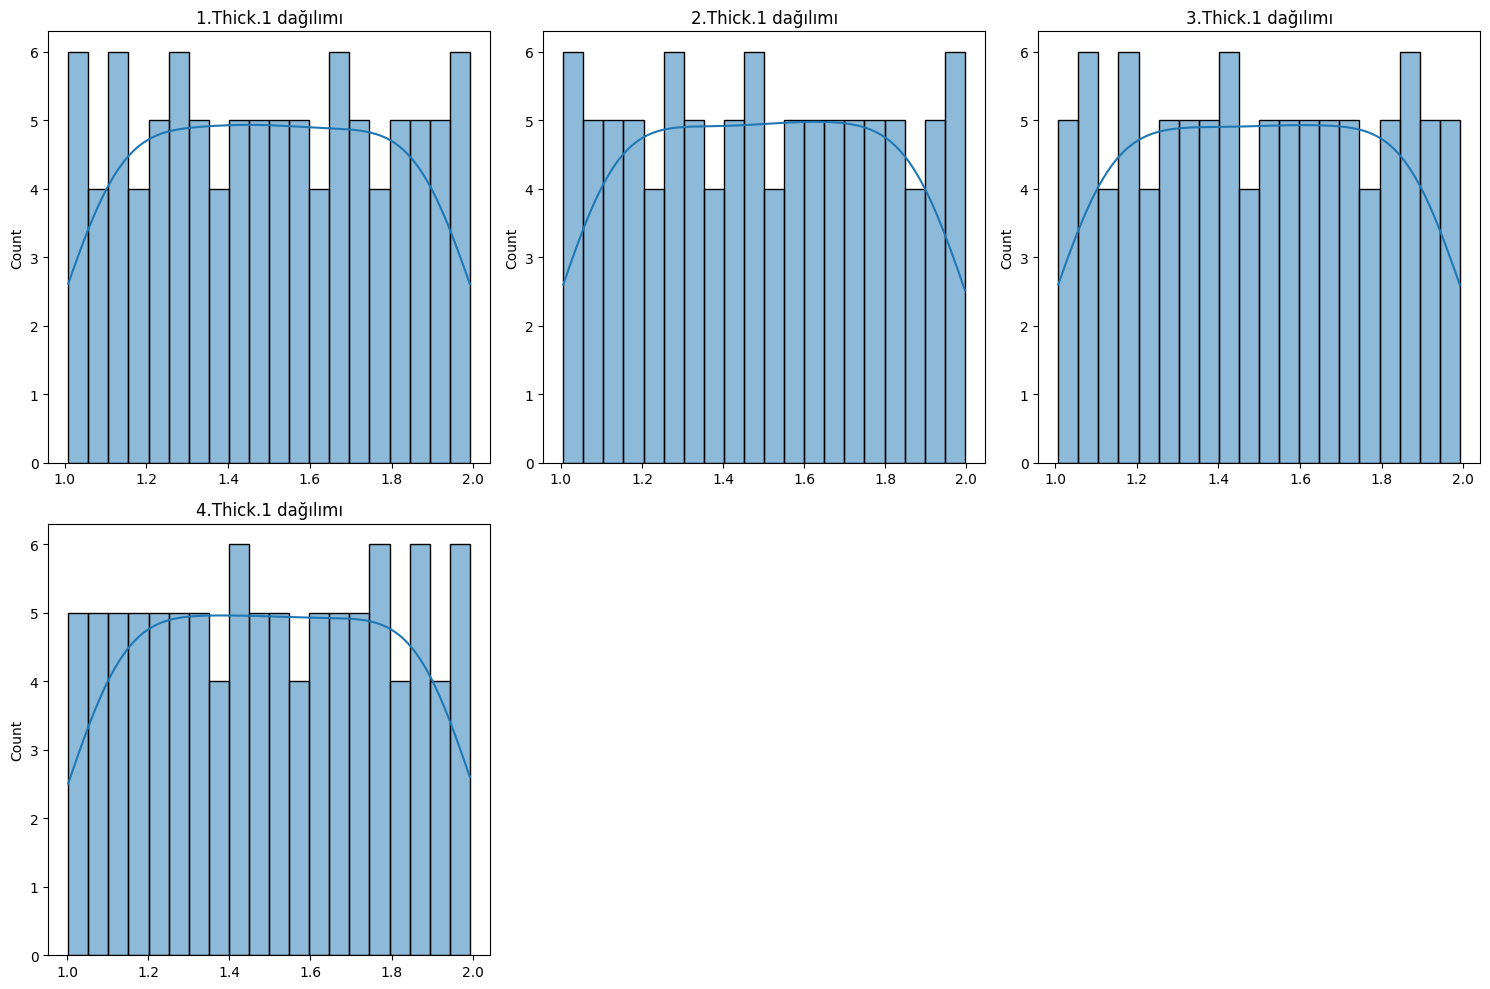

In [ ]:
# Girdiler için histogramlar
inputs = ['1.Thick.1',
           '2.Thick.1',
           '3.Thick.1',
           '4.Thick.1']

plt.figure(figsize=(15, 10))

for i, col in enumerate(inputs, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col], kde=True, bins=20)
    plt.title(f"{col} dağılımı")

plt.tight_layout()
plt.show()

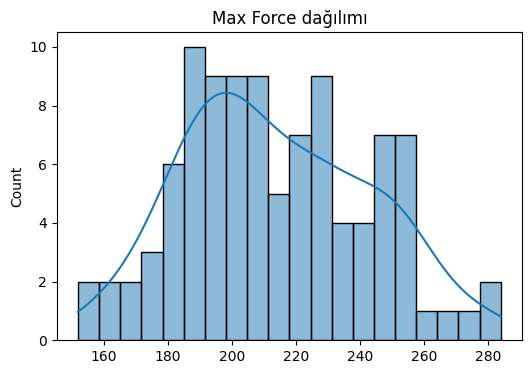

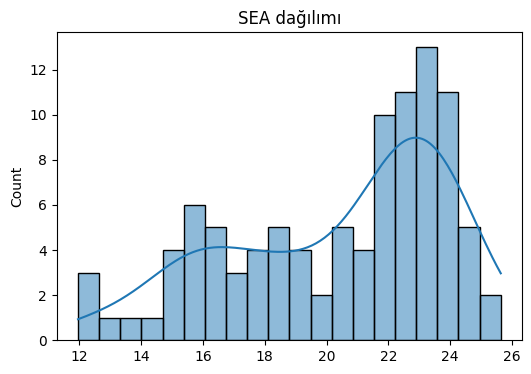

In [ ]:
# Çıktılar için histogramlar

# Max Force (Maksimum kuvvet) için
plt.figure(figsize=(6,4))
sns.histplot(df["max force"], kde=True, bins=20)
plt.title("Max Force dağılımı")
plt.show()

# SEA için
plt.figure(figsize=(6,4))
sns.histplot(df["SEA"], kde=True, bins=20)
plt.title("SEA dağılımı")
plt.show()

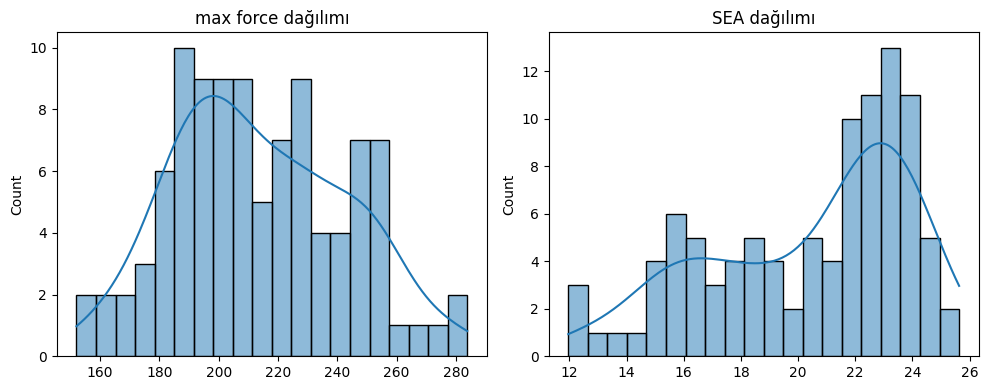

In [ ]:
outputs = ["max force", "SEA"]

plt.figure(figsize=(10,4))

for i, col in enumerate(outputs, 1):
    plt.subplot(1, 2, i)
    sns.histplot(df[col], kde=True, bins=20)
    plt.title(f"{col} dağılımı")

plt.tight_layout()
plt.show()

In [ ]:
columns = ["1.Thick.1", "2.Thick.1","3.Thick.1","4.Thick.1", "max force","SEA"]
for col in columns:
    print(f"{col}:")
    print(f"  Skewness: {df[col].skew():.2f}")
    print(f"  Kurtosis: {df[col].kurtosis():.2f}\n")

1.Thick.1:
  Skewness: 0.00
  Kurtosis: -1.20

2.Thick.1:
  Skewness: -0.00
  Kurtosis: -1.20

3.Thick.1:
  Skewness: -0.00
  Kurtosis: -1.20

4.Thick.1:
  Skewness: 0.00
  Kurtosis: -1.20

max force:
  Skewness: 0.25
  Kurtosis: -0.62

SEA:
  Skewness: -0.64
  Kurtosis: -0.78



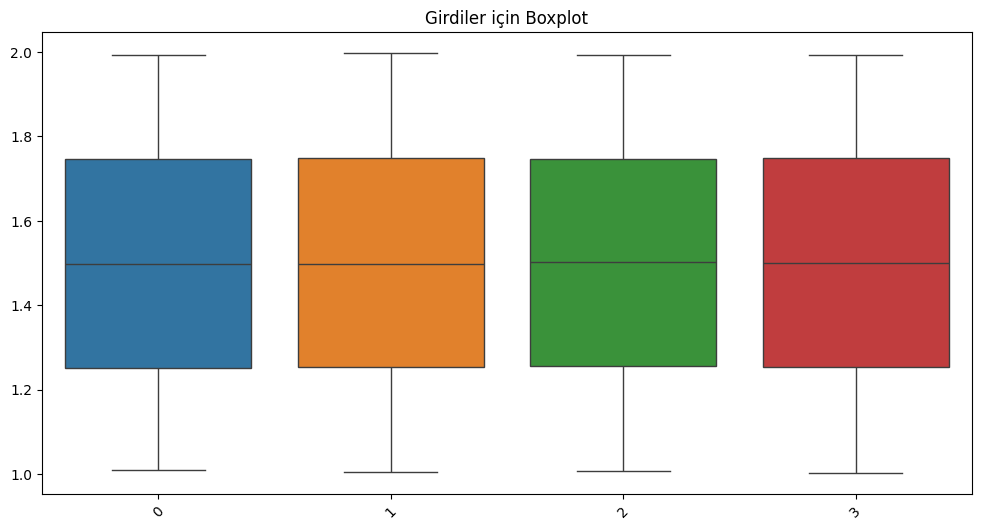

In [ ]:
# Girdiler için box plot oluştur
inputs = ["1.Thick.1", "2.Thick.1","3.Thick.1","4.Thick.1"]

plt.figure(figsize=(12, 6))

sns.boxplot(data=df[inputs])
plt.title("Girdiler için Boxplot")
plt.xticks(rotation=45)

plt.show()

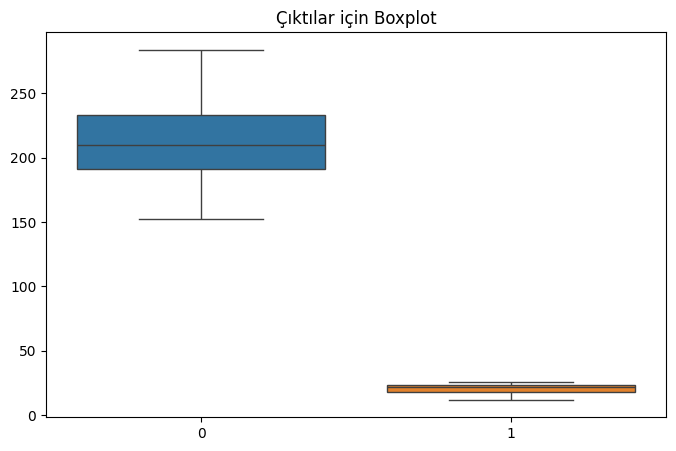

In [ ]:
# Çıktılar için box plot
outputs = ["max force", "SEA"]

plt.figure(figsize=(8,5))
sns.boxplot(data=df[outputs])

plt.title("Çıktılar için Boxplot")
plt.show()

In [ ]:
df.head(5)

Evaluation Index,1.Thick.1,2.Thick.1,3.Thick.1,4.Thick.1,mass,max force,mean force,displacement,EA,SEA,CFE
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1,1.093949,1.342199,1.732571,1.819928,0.000535,184.723234,117.586523,107.757446,12.670823,23.703298,0.636555
2,1.920155,1.368645,1.401445,1.165773,0.000654,229.676828,148.677631,80.014755,11.896404,18.180804,0.647334
3,1.222035,1.254302,1.786731,1.272973,0.000519,178.541438,112.677972,111.210312,12.530952,24.144615,0.631103
4,1.419633,1.091302,1.957286,1.237966,0.000548,187.879281,128.413836,100.977074,12.966853,23.672848,0.683491
5,1.585031,1.313174,1.134996,1.155085,0.00057,198.293797,130.951394,98.505051,12.899374,22.644488,0.660391


In [ ]:
import polars.selectors as cs

# Sadece sayısal sütunları seç
numeric_df = df.select(cs.numeric())

for col in numeric_df.columns:
    Q1 = numeric_df[col].quantile(0.25, interpolation="linear")
    Q3 = numeric_df[col].quantile(0.75, interpolation="linear")
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_count = ((numeric_df[col] < lower) | (numeric_df[col] > upper)).sum()

    print(f"{col}: {outlier_count} outlier")

Evaluation Index: 0 outlier
1.Thick.1: 0 outlier
2.Thick.1: 0 outlier
3.Thick.1: 0 outlier
4.Thick.1: 0 outlier
mass: 0 outlier
max force: 0 outlier
mean force: 0 outlier
displacement: 0 outlier
EA: 2 outlier
SEA: 0 outlier
CFE: 0 outlier


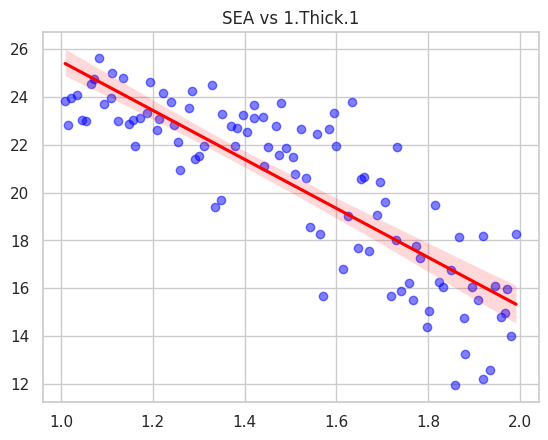

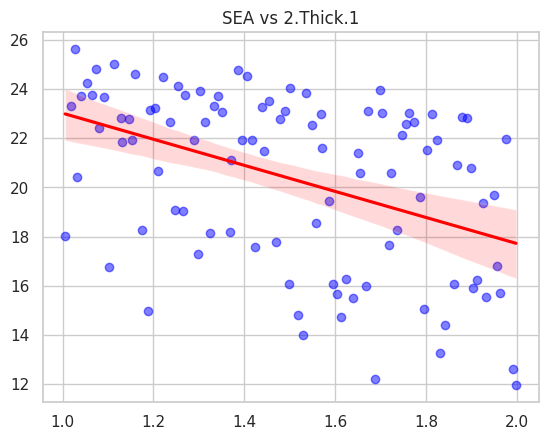

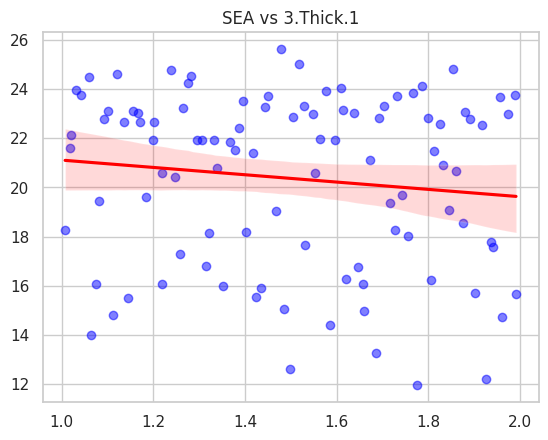

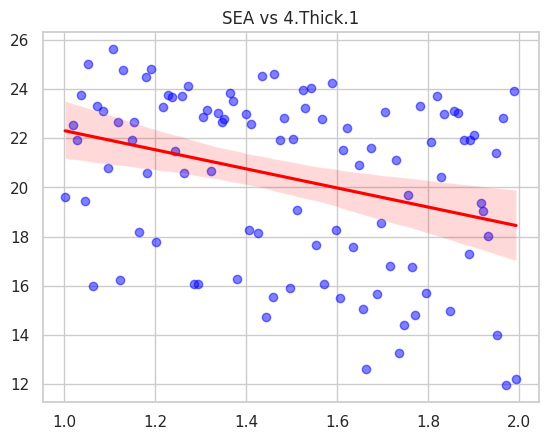

In [ ]:
inputs = ["1.Thick.1", "2.Thick.1","3.Thick.1","4.Thick.1"]
output = "SEA"

sns.set(style="whitegrid")

for col in inputs:
    sns.regplot(x=df[col],
                y=df[output],
                scatter_kws={"alpha":0.5, "color":"blue"},
                line_kws={"color":"red"}
               )

    plt.title(f"{output} vs {col}")
    plt.show()

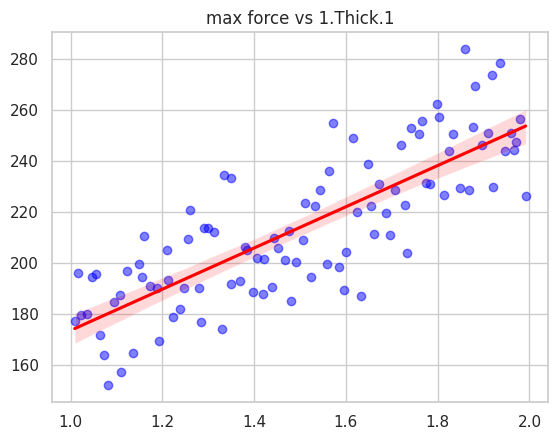

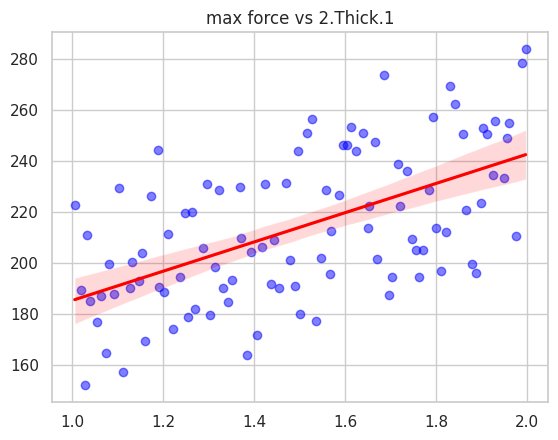

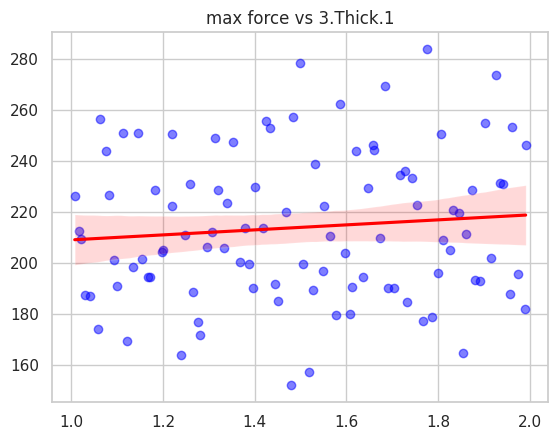

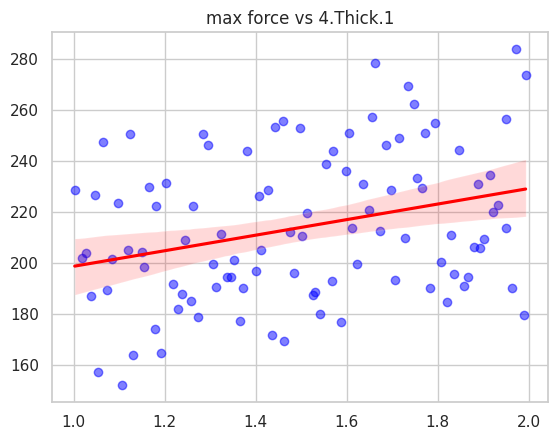

In [ ]:
inputs = ["1.Thick.1", "2.Thick.1","3.Thick.1","4.Thick.1"]
output = "max force"

sns.set(style="whitegrid")

for col in inputs:
    sns.regplot(x=df[col],
                y=df[output],
                scatter_kws={"alpha":0.5, "color":"blue"},
                line_kws={"color":"red"}
               )
    plt.title(f"{output} vs {col}")
    plt.show()

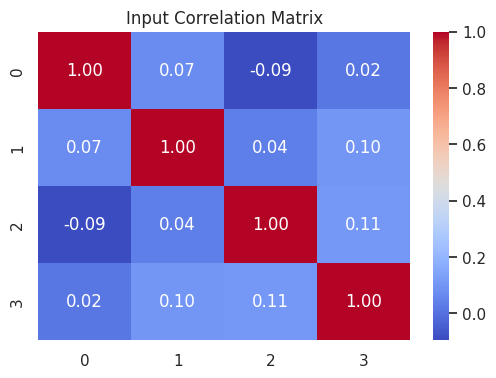

In [ ]:
# Korelasyon ilişkisi var mı?

corr_matrix = df[inputs].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Input Correlation Matrix")
plt.show()

In [ ]:
# korelesyon değeri 0.8 i geçerse ekrana bas
threshold = 0.8

for i in range(len(inputs)):
    for j in range(i + 1, len(inputs)):
        corr_value = df.select(
            pl.corr(inputs[i], inputs[j])
        ).item()

        if abs(corr_value) > threshold:
            print(f"{inputs[i]} - {inputs[j]}: {corr_value:.2f}")

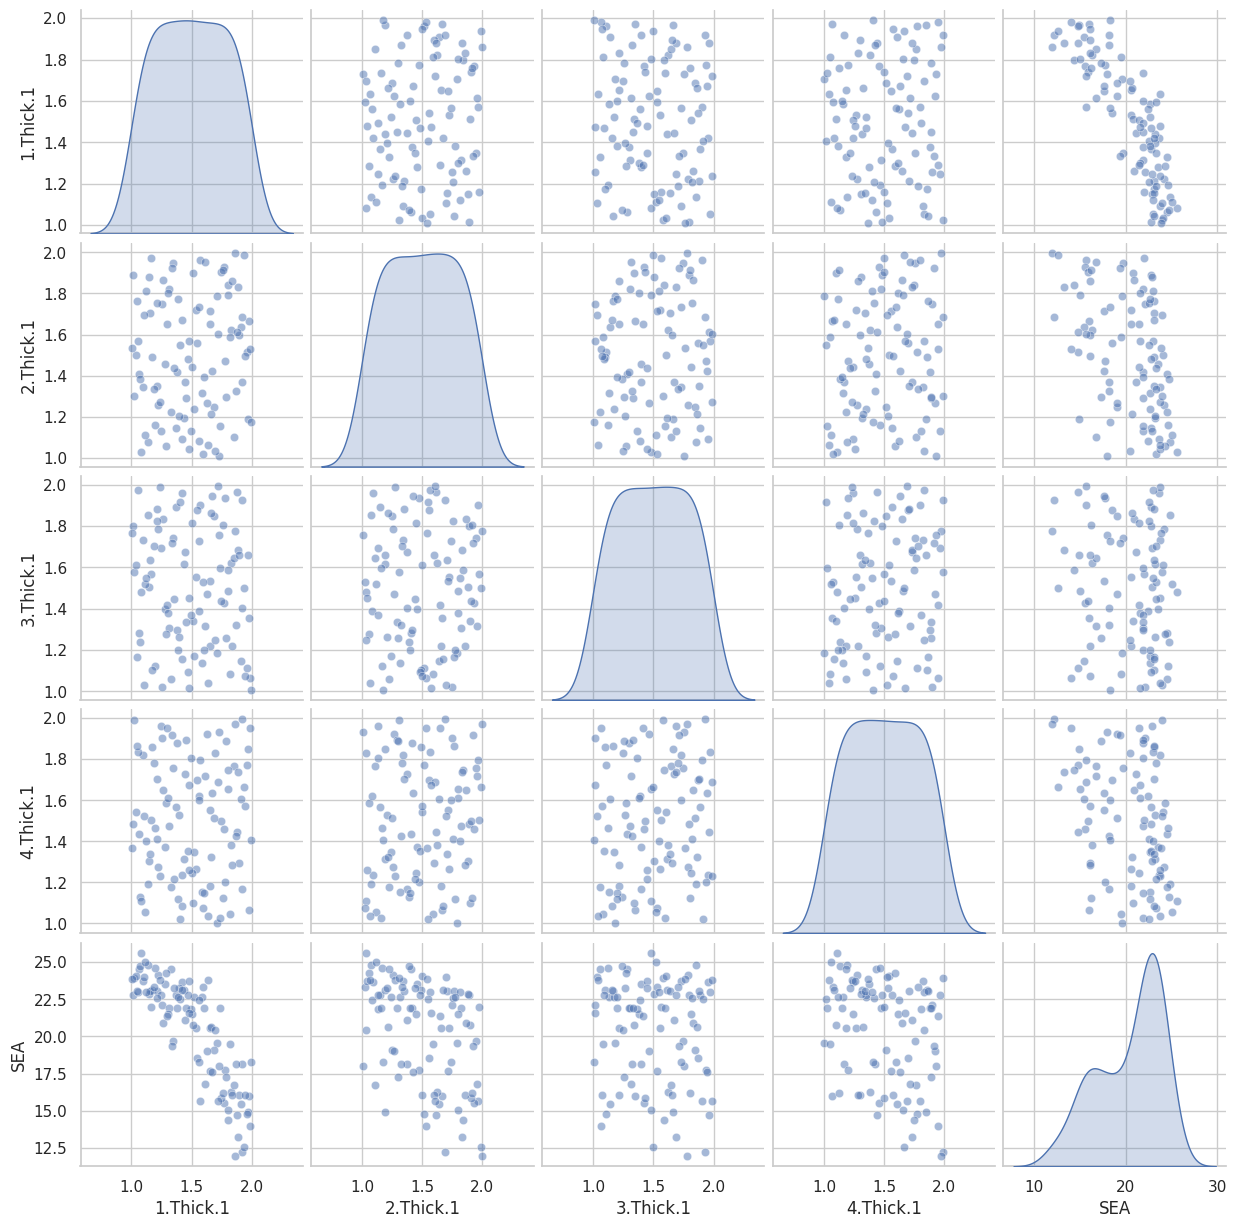

In [ ]:
# SEA çıktısı için pairplot


cols = ["1.Thick.1", "2.Thick.1", "3.Thick.1", "4.Thick.1", "SEA"]

sns.pairplot(df.select(cols).to_pandas(),
             diag_kind="kde",
             plot_kws={"alpha": 0.5})

plt.show()

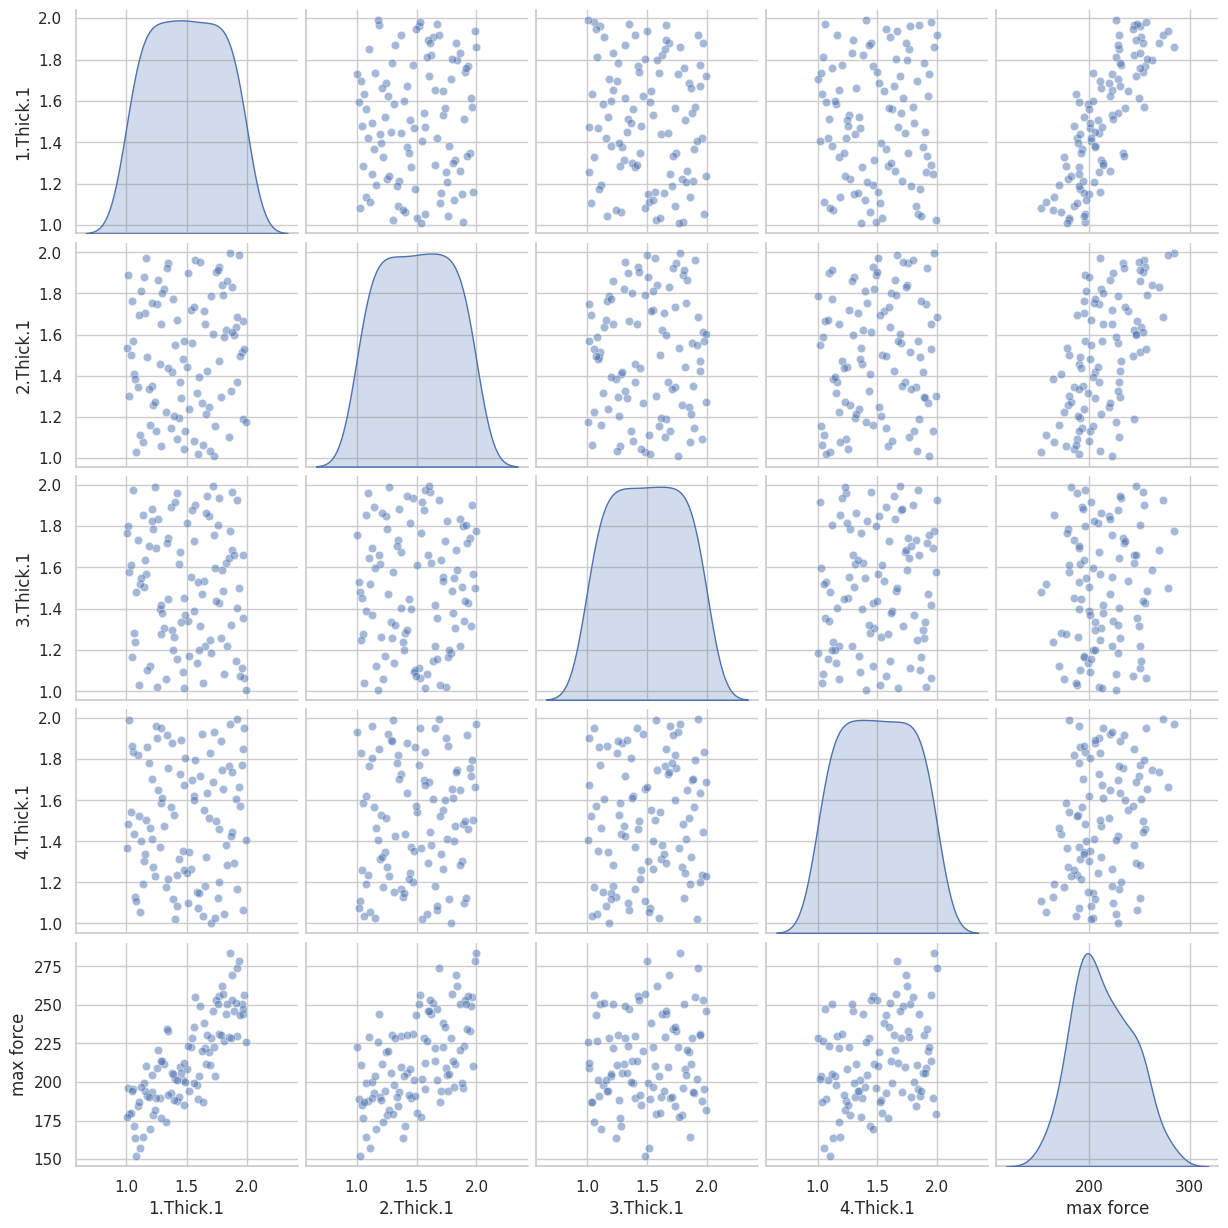

In [ ]:
# max force çıktısı için pairplot

cols = ["1.Thick.1", "2.Thick.1","3.Thick.1","4.Thick.1", "max force"]

sns.pairplot(df.select(cols).to_pandas(),
             diag_kind="kde",
            plot_kws={"alpha": 0.5})

plt.show()

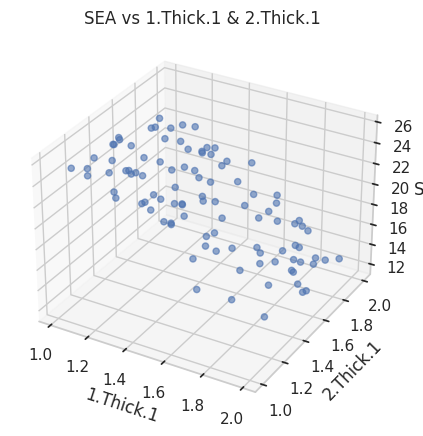

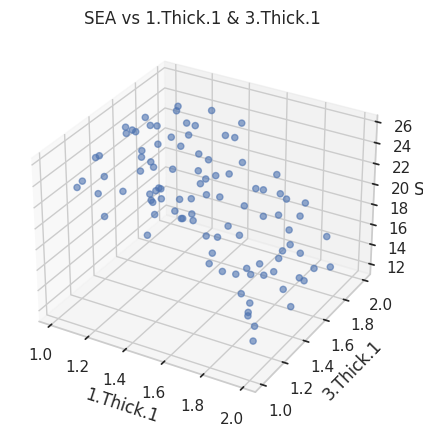

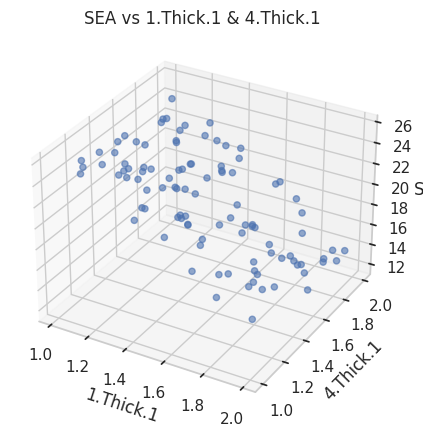

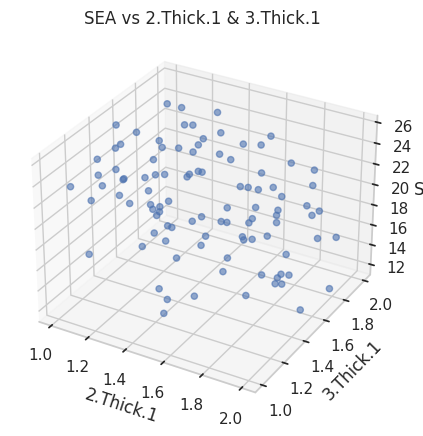

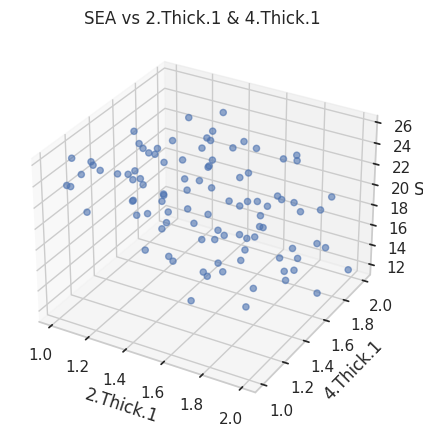

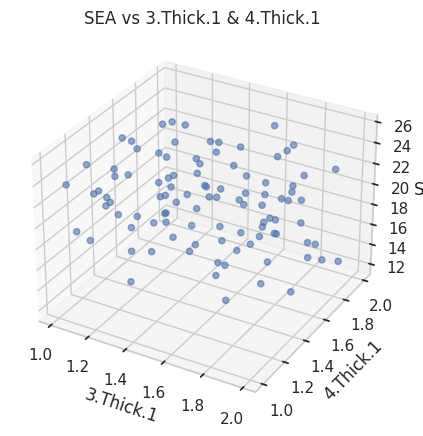

In [ ]:
from itertools import combinations

inputs = ["1.Thick.1", "2.Thick.1","3.Thick.1","4.Thick.1"]
y = "SEA"

for x1, x2 in combinations(inputs, 2):
    fig = plt.figure(figsize=(6,5))
    ax = fig.add_subplot(111, projection='3d')

    ax.scatter(df[x1], df[x2], df[y], alpha=0.6)

    ax.set_xlabel(x1)
    ax.set_ylabel(x2)
    ax.set_zlabel(y)

    plt.title(f"{y} vs {x1} & {x2}")
    plt.show()

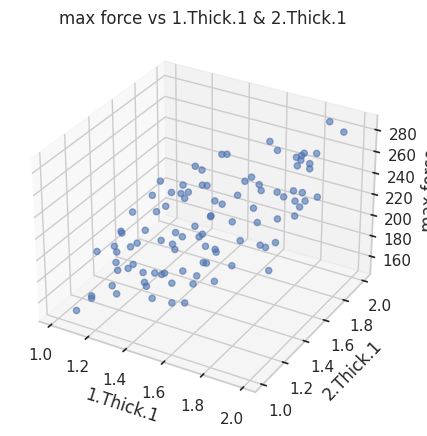

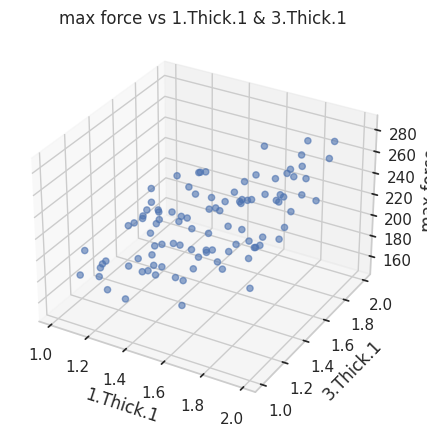

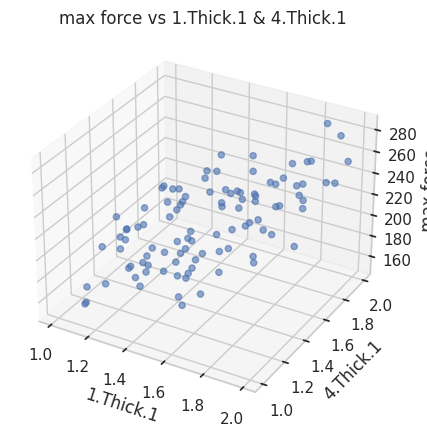

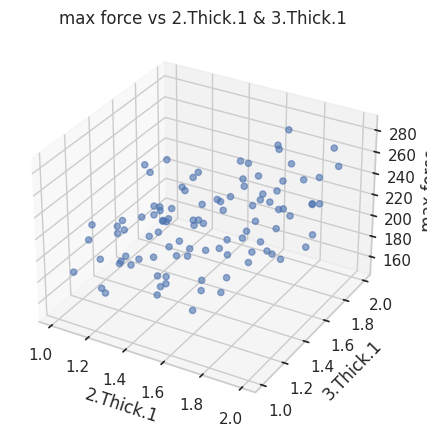

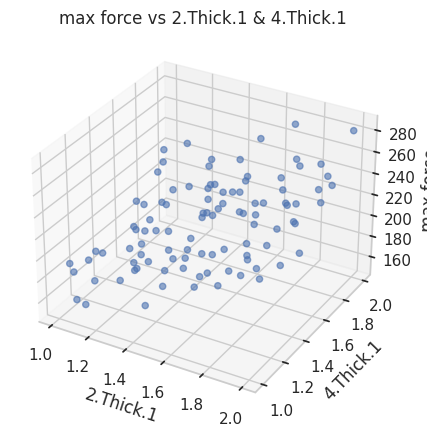

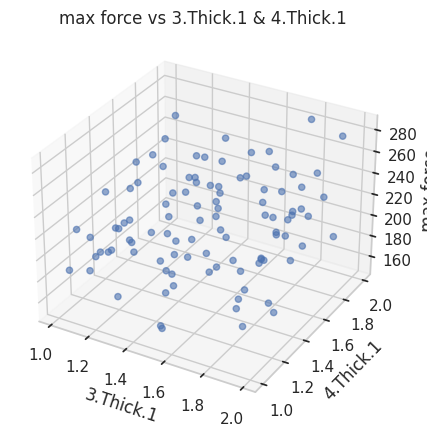

In [ ]:
from itertools import combinations

inputs = ["1.Thick.1", "2.Thick.1","3.Thick.1","4.Thick.1"]
y = "max force"

for x1, x2 in combinations(inputs, 2):
    fig = plt.figure(figsize=(6,5))
    ax = fig.add_subplot(111, projection='3d')

    ax.scatter(df[x1], df[x2], df[y], alpha=0.6)

    ax.set_xlabel(x1)
    ax.set_ylabel(x2)
    ax.set_zlabel(y)

    plt.title(f"{y} vs {x1} & {x2}")
    plt.show()

In [ ]:
# Model oluştur

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# Verileri Yükle
X = df.select(['1.Thick.1', '2.Thick.1', '3.Thick.1', '4.Thick.1'])
y = df.select(['max force', 'SEA'])

In [ ]:
# Train-Test Ayrımı yap
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# GPR Modeli Kurulumu
# RBF çekirdeği
kernel = C(1.0, (1e-3, 1e3)) * RBF(10, (1e-2, 1e2))
gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=0.1)

# Çoklu çıktı için model
model = MultiOutputRegressor(gpr)
model.fit(X_train_scaled, y_train)

# Tahmin ve Değerlendirme
y_pred = model.predict(X_test_scaled)

/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/_gpr.py:660: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


In [ ]:
print(f"Max Force R2 Skoru: {r2_score(y_test.to_series(0).to_numpy(), y_pred[:, 0]):.4f}")
print(f"SEA (EA) R2 Skoru: {r2_score(y_test.to_series(1).to_numpy(), y_pred[:, 1]):.4f}")

Max Force R2 Skoru: 0.9996
SEA (EA) R2 Skoru: 0.9935


In [ ]:
from sklearn.model_selection import cross_val_score

X_scaled = scaler.fit_transform(X)

# y_train kullanın, y değil
cv_scores_max_force = cross_val_score(
    model.estimators_[0],
    X_train_scaled,
    y_train.to_series(0).to_numpy(),
    cv=5,
    scoring='r2'
)

cv_scores_sea = cross_val_score(
    model.estimators_[1],
    X_train_scaled,
    y_train.to_series(1).to_numpy(),
    cv=5,
    scoring='r2'
)

print(f"Max Force CV R2 Skorları: {cv_scores_max_force}")
print(f"Max Force Ortalama R2: {cv_scores_max_force.mean():.4f}")
print("-" * 30)
print(f"SEA CV R2 Skorları: {cv_scores_sea}")
print(f"SEA Ortalama R2: {cv_scores_sea.mean():.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: Converg

Max Force CV R2 Skorları: [0.99636122 0.99955708 0.99968679 0.99977071 0.99949484]
Max Force Ortalama R2: 0.9990
------------------------------
SEA CV R2 Skorları: [0.98984697 0.99367855 0.99220247 0.99157361 0.98828195]
SEA Ortalama R2: 0.9911


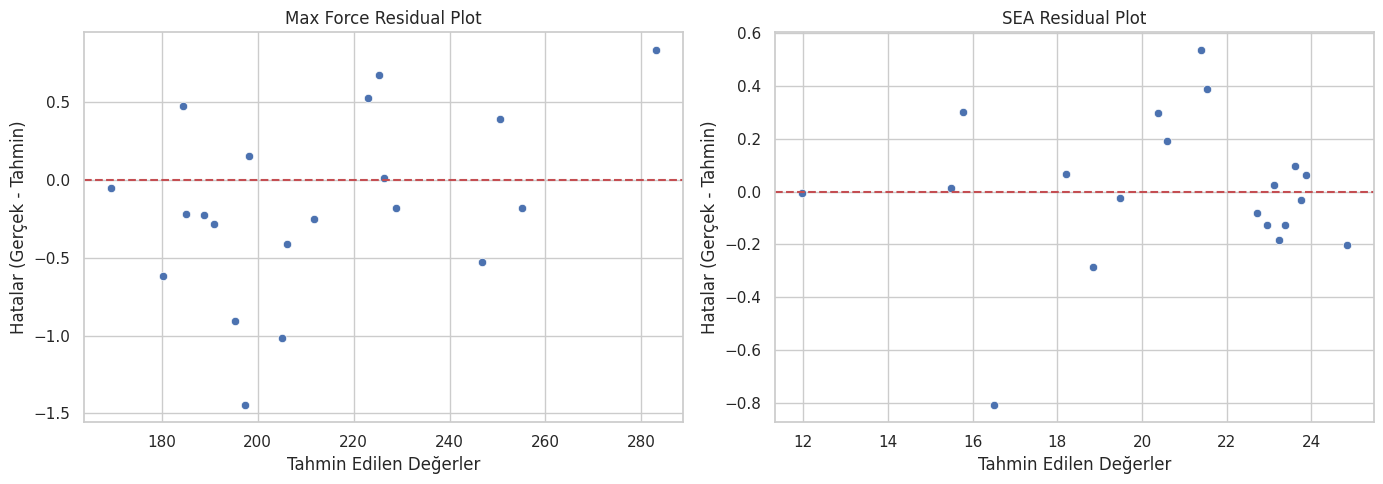

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Hataları  hesapla
residuals_max_force = y_test.to_series(0).to_numpy() - y_pred[:, 0]
residuals_sea = y_test.to_series(1).to_numpy() - y_pred[:, 1]

plt.figure(figsize=(14, 5))

# Max Force Residuals
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_pred[:, 0], y=residuals_max_force)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Max Force Residual Plot')
plt.xlabel('Tahmin Edilen Değerler')
plt.ylabel('Hatalar (Gerçek - Tahmin)')

# SEA Residuals
plt.subplot(1, 2, 2)
sns.scatterplot(x=y_pred[:, 1], y=residuals_sea)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('SEA Residual Plot')
plt.xlabel('Tahmin Edilen Değerler')
plt.ylabel('Hatalar (Gerçek - Tahmin)')

plt.tight_layout()
plt.show()

<Axes: >

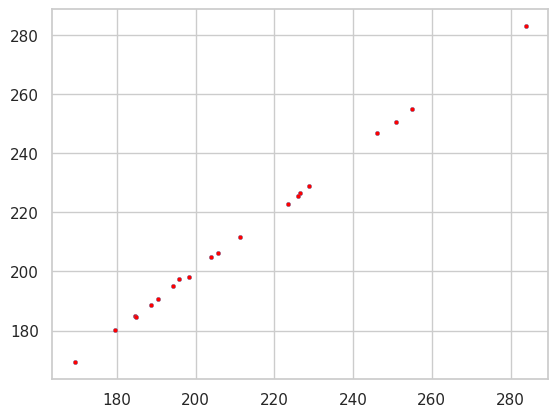

In [ ]:
# noktaları belirginleştir
sns.scatterplot(x=y_test.to_series(0).to_numpy(), y=y_pred[:, 0], s=10, facecolors='red', edgecolors='b')